# NetworkX playground: graphs in Python

**Session 08 — Graphs and Graph Metrics**

This notebook is a hands-on tour of `networkx`, the de-facto Python library for working with graphs. By the end you should be comfortable with:

- building, drawing, and measuring a graph
- computing centrality scores (degree / betweenness / closeness / PageRank)
- understanding what PageRank actually computes — we re-implement it in ~10 lines of NumPy and verify it matches `nx.pagerank` to numerical precision

**Run:**
```bash
pip install networkx matplotlib numpy
```

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 1. Build a graph from scratch

A `networkx.Graph` holds a set of nodes and a set of edges. The simplest way to build one is from an edge list. Nodes can be any hashable Python object — strings, integers, tuples, even custom classes.

In [7]:
# A tiny made-up friendship network
edges = [
    ("Alice", "Bob"), ("Alice", "Charlie"), ("Bob", "Charlie"),       # triangle 1
    ("Charlie", "Diana"),                                              # bridge
    ("Diana", "Eve"), ("Diana", "Frank"), ("Eve", "Frank"),            # triangle 2
    ("Frank", "George"), ("George", "Helen"),                          # tail
]

G = nx.Graph()
G.add_edges_from(edges)

print(f"Nodes ({G.number_of_nodes()}):  {list(G.nodes())}")
print(f"Edges ({G.number_of_edges()}):  {list(G.edges())}")

Nodes (8):  ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'George', 'Helen']
Edges (9):  [('Alice', 'Bob'), ('Alice', 'Charlie'), ('Bob', 'Charlie'), ('Charlie', 'Diana'), ('Diana', 'Eve'), ('Diana', 'Frank'), ('Eve', 'Frank'), ('Frank', 'George'), ('George', 'Helen')]


## 2. Drawing it: layouts

The graph itself has no notion of *position*. Visualising it requires a **layout** — a function that returns a `{node: (x, y)}` dict. NetworkX ships several:

- `spring_layout` — physics simulation: edges are springs, nodes repel.
- `circular_layout` — nodes on a circle.
- `kamada_kawai_layout` — energy-minimisation, often the prettiest.
- `shell_layout` — concentric circles.

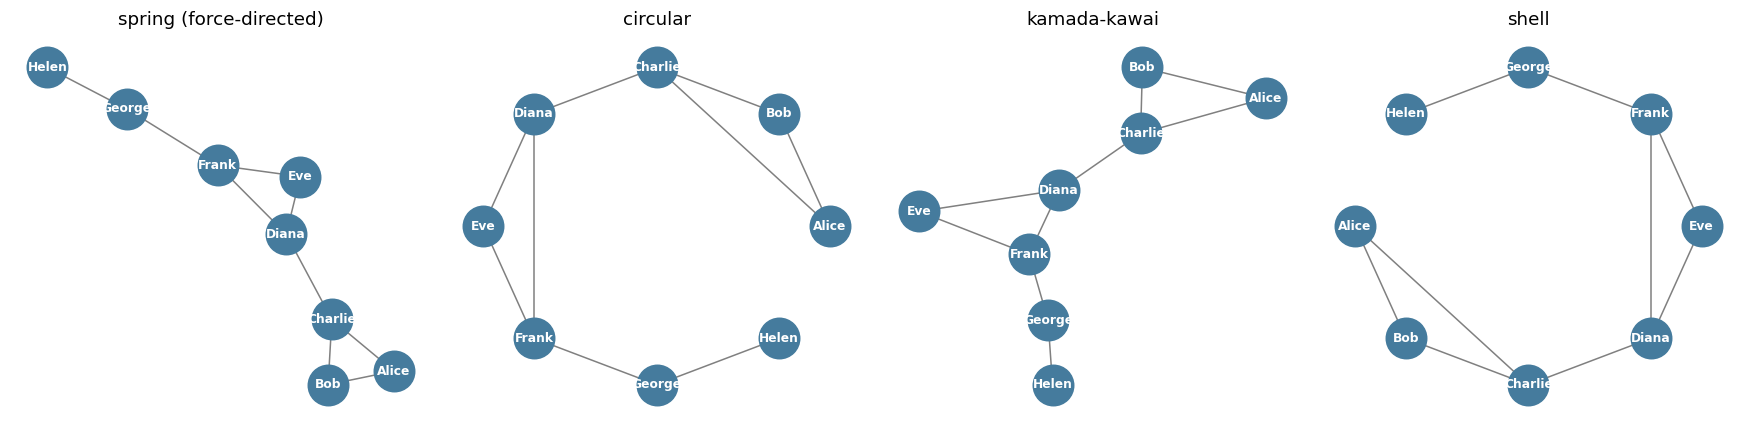

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
layouts = [
    ("spring (force-directed)", nx.spring_layout(G, seed=0)),
    ("circular",                 nx.circular_layout(G)),
    ("kamada-kawai",             nx.kamada_kawai_layout(G)),
    ("shell",                    nx.shell_layout(G)),
]
for ax, (name, pos) in zip(axes, layouts):
    nx.draw_networkx(G, pos, ax=ax, node_color='#457b9d', node_size=700,
                     font_color='white', font_weight='bold', font_size=8,
                     edge_color='gray')
    ax.set_title(name); ax.set_axis_off()
plt.tight_layout(); plt.show()

## 3. Basic stats

A handful of one-liners that summarise a graph. Notice the **degree** of *Charlie* and *Diana* — they are the bridge between the two triangles, so they have more connections than anyone else.

#nodes:   8
#edges:   9
density:  0.321    (fraction of all possible edges that are present)

Degrees (number of friends each node has):
  Charlie    3
  Diana      3
  Frank      3
  Alice      2
  Bob        2
  Eve        2
  George     2
  Helen      1


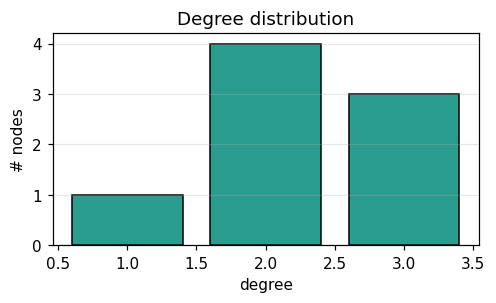

In [12]:
print(f"#nodes:   {G.number_of_nodes()}")
print(f"#edges:   {G.number_of_edges()}")
print(f"density:  {nx.density(G):.3f}    (fraction of all possible edges that are present)") #d = 2m/n*(n-1) m edges, n nodes
print("\nDegrees (number of friends each node has):")
for node, deg in sorted(G.degree(), key=lambda x: -x[1]):
    print(f"  {node:<10} {deg}")

# Degree distribution
degrees = [d for _, d in G.degree()]
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.bar(range(min(degrees), max(degrees) + 1),
       [degrees.count(d) for d in range(min(degrees), max(degrees) + 1)],
       color='#2a9d8f', edgecolor='black')
ax.set_xlabel('degree'); ax.set_ylabel('# nodes')
ax.set_title('Degree distribution'); ax.grid(alpha=0.3, axis='y')
plt.show()

## 4. A real graph: Zachary's Karate Club

In 1977 Wayne Zachary studied a karate club at a US university for two years. During his study the club split into two factions over a dispute between Mr. Hi (the instructor) and the club president. The famous result: the **friendship ties he had recorded beforehand predicted, with one mistake, who would join which faction**.

NetworkX ships the data built-in. 34 members, 78 friendship edges, plus a `'club'` attribute on every node telling us which faction they ended up in.

34 nodes, 78 edges, density 0.139
Mr Hi's faction: 17 members  |  Officer's faction: 17 members


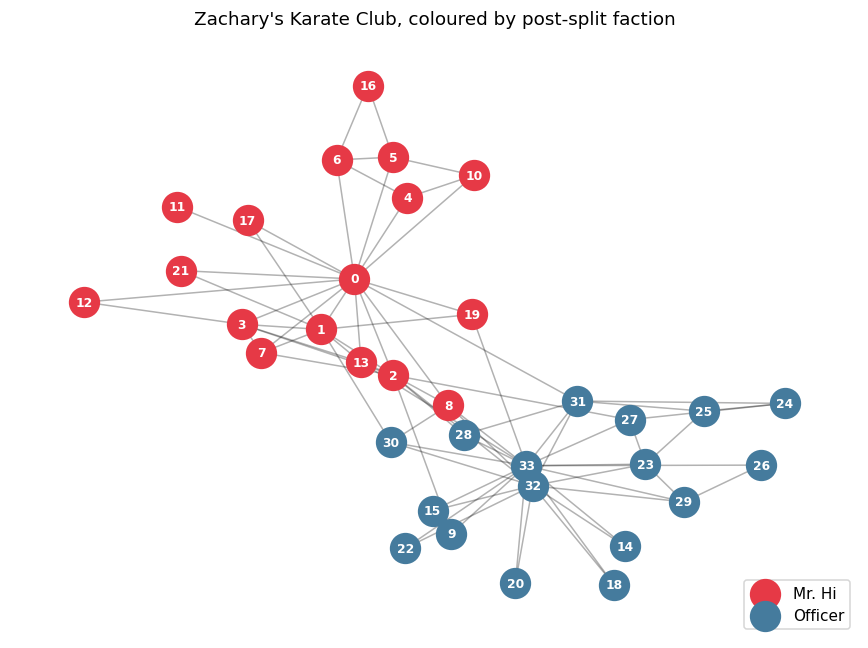

In [14]:
K = nx.karate_club_graph()
print(f"{K.number_of_nodes()} nodes, {K.number_of_edges()} edges, density {nx.density(K):.3f}")

clubs = nx.get_node_attributes(K, 'club')
mr_hi   = [n for n, c in clubs.items() if c == 'Mr. Hi']
officer = [n for n, c in clubs.items() if c == 'Officer']
print(f"Mr Hi's faction: {len(mr_hi)} members  |  Officer's faction: {len(officer)} members")

fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(K, seed=42)
nx.draw_networkx_edges(K, pos, ax=ax, alpha=0.3)
nx.draw_networkx_nodes(K, pos, ax=ax, nodelist=mr_hi,   node_color='#e63946', node_size=380, label="Mr. Hi")
nx.draw_networkx_nodes(K, pos, ax=ax, nodelist=officer, node_color='#457b9d', node_size=380, label="Officer")
nx.draw_networkx_labels(K, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.set_title("Zachary's Karate Club, coloured by post-split faction")
ax.legend(loc='lower right'); ax.set_axis_off()
plt.tight_layout(); plt.show()

## 5. Who matters? Centrality measures

*Centrality* is a family of metrics that try to score how **important** each node is. Different definitions of importance give different scores:

- **Degree centrality** — how many friends do you have? (raw popularity)
- **Betweenness centrality** — how often do you sit on the shortest path between two other nodes? (broker / gatekeeper)
- **Closeness centrality** — how short is your average shortest-path distance to everyone else? (everyone-can-reach-you)
- **PageRank** — Google's twist: a friend of an important person is themselves important, recursively. The eigenvector-flavoured one.

Each is a one-line call in NetworkX. We compute all four on the Karate Club and visualise them as node colours, with the top-3 nodes labelled per metric.

**Watch for:** *node 0* (Mr. Hi) and *node 33* (Officer) are central by every metric — they're the leaders of the two factions. *Nodes 32* and *2* often appear too — they're well-connected hubs. *Node 31* tends to score very high on betweenness specifically — it sits on the shortest path between the two communities, which is exactly what betweenness rewards.

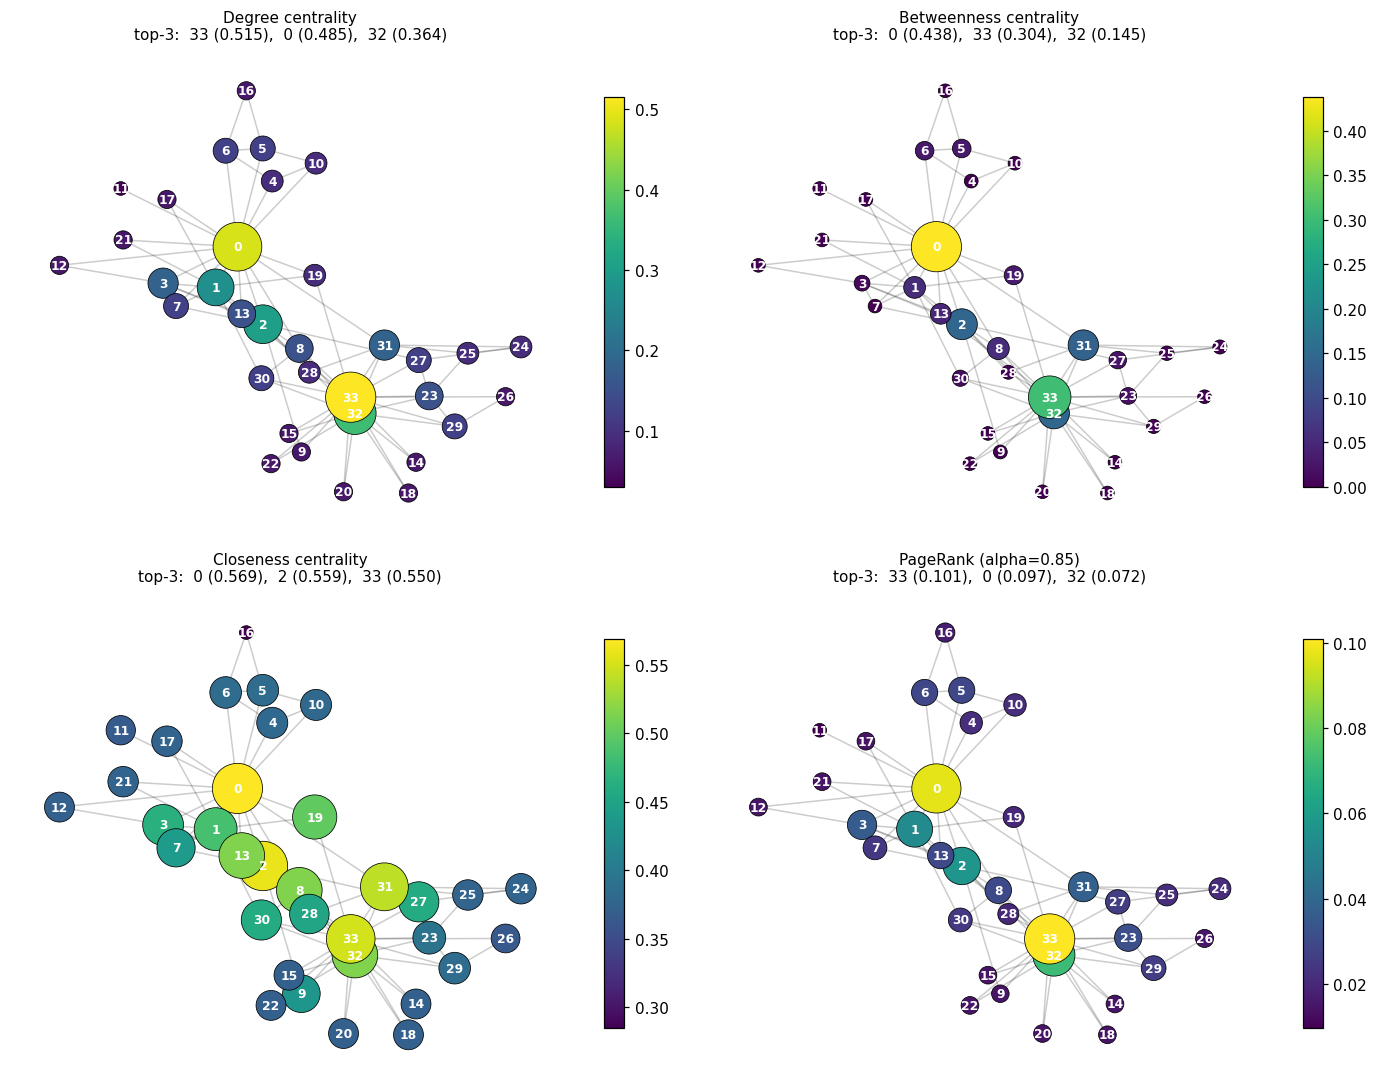

In [15]:
metrics = {
    "Degree centrality":      nx.degree_centrality(K),
    "Betweenness centrality": nx.betweenness_centrality(K),
    "Closeness centrality":   nx.closeness_centrality(K),
    "PageRank (alpha=0.85)":  nx.pagerank(K, alpha=0.85, weight=None),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
pos = nx.spring_layout(K, seed=42)

for ax, (name, scores) in zip(axes.flat, metrics.items()):
    vals = np.array([scores[n] for n in K.nodes()])
    sizes = 80 + 1000 * (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    nx.draw_networkx_edges(K, pos, ax=ax, alpha=0.2)
    nodes = nx.draw_networkx_nodes(K, pos, ax=ax, node_color=vals, cmap='viridis',
                                   node_size=sizes, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_labels(K, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')

    plt.colorbar(nodes, ax=ax, shrink=0.8)
    top3 = sorted(scores.items(), key=lambda x: -x[1])[:3]
    ax.set_title(f"{name}\ntop-3:  " + ",  ".join(f"{n} ({s:.3f})" for n, s in top3),
                 fontsize=10)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig('centralities.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. PageRank from scratch — what is NetworkX actually doing?

`nx.pagerank(K)` looks like a black box. It isn't. PageRank says: **a node is important if important nodes link to it**. Formally, with damping $\alpha = 0.85$ (the canonical Google value) and uniform teleport over $N$ nodes,

$$\mathbf{r}^{(t+1)} \;=\; \alpha \, M \, \mathbf{r}^{(t)} \;+\; (1 - \alpha) \, \frac{\mathbf{1}}{N}$$

where $M_{ij} = 1 / d_j$ if $j$ has an edge to $i$, else $0$. We iterate until $\mathbf{r}$ stops moving. (For undirected graphs, every edge is treated as bi-directional.)

Below: ten lines of NumPy that match `nx.pagerank` to seven decimal places.

In [16]:
def pagerank_from_scratch(G, alpha=0.85, n_iter=200, tol=1e-9):
    nodes = list(G.nodes())
    N = len(nodes)
    idx = {n: i for i, n in enumerate(nodes)}

    # Column-stochastic transition matrix:  M[i, j] = 1/deg(j) if j -> i
    M = np.zeros((N, N))
    for u in nodes:
        deg = G.degree(u)
        if deg == 0:
            continue
        for v in G.neighbors(u):
            M[idx[v], idx[u]] = 1.0 / deg

    r = np.full(N, 1.0 / N)        # uniform start
    for it in range(n_iter):
        r_new = alpha * (M @ r) + (1 - alpha) / N
        if np.max(np.abs(r_new - r)) < tol:
            print(f"Converged after {it + 1} iterations")
            break
        r = r_new
    return dict(zip(nodes, r))


ours   = pagerank_from_scratch(K)
theirs = nx.pagerank(K, alpha=0.85, weight=None)   # weight=None: ignore edge weights, match our unweighted impl

print(f"\n{'node':<6}{'ours':>12}{'networkx':>14}{'|diff|':>12}")
print("-" * 44)
for n in sorted(K.nodes(), key=lambda x: -ours[x])[:8]:
    print(f"{n:<6}{ours[n]:>12.6f}{theirs[n]:>14.6f}{abs(ours[n] - theirs[n]):>12.2e}")

Converged after 45 iterations

node          ours      networkx      |diff|
--------------------------------------------
33        0.100919      0.100918    1.26e-06
0         0.096997      0.097002    4.53e-06
32        0.071693      0.071692    1.09e-06
2         0.057079      0.057078    8.64e-08
1         0.052877      0.052878    1.47e-06
31        0.037158      0.037157    1.45e-06
3         0.035860      0.035861    7.85e-07
23        0.031523      0.031521    1.60e-06


## 7. PageRank really wants a directed graph

PageRank was invented for the **web**, which is directed (page A links to page B; B doesn't necessarily link back). On undirected graphs PageRank is somewhat correlated with degree. On directed graphs, by contrast, PageRank can be very different from in-degree — a page with few but well-chosen incoming links can outrank a page with many spammy incoming links.

Tiny example: a 4-page web.

page     in-degree    PageRank
------------------------------
C                3      0.3942
A                1      0.3725
B                1      0.1958
D                0      0.0375


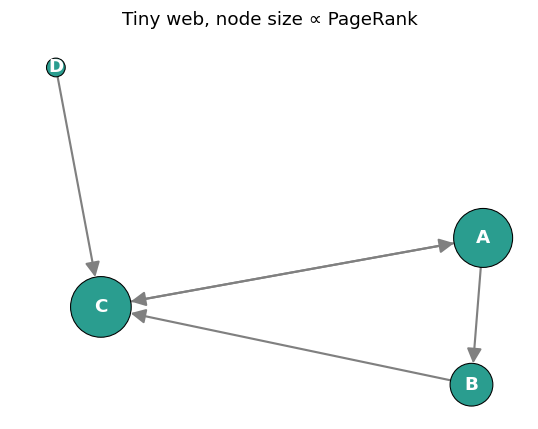

In [17]:
W = nx.DiGraph([
    ('A', 'B'),  ('A', 'C'),
    ('B', 'C'),
    ('C', 'A'),
    ('D', 'C'),
])

pr = nx.pagerank(W, alpha=0.85)
ind = dict(W.in_degree())

print(f"{'page':<6}{'in-degree':>12}{'PageRank':>12}")
print("-" * 30)
for n in sorted(pr, key=lambda x: -pr[x]):
    print(f"{n:<6}{ind[n]:>12}{pr[n]:>12.4f}")

# Visualise: node size by PageRank
fig, ax = plt.subplots(figsize=(5, 4))
pos = nx.spring_layout(W, seed=0)
sizes = [4000 * pr[n] for n in W.nodes()]
nx.draw_networkx_nodes(W, pos, ax=ax, node_color='#2a9d8f', node_size=sizes,
                       edgecolors='black', linewidths=0.7)
nx.draw_networkx_edges(W, pos, ax=ax, arrows=True, arrowsize=20, edge_color='gray',
                       node_size=sizes, width=1.4)
nx.draw_networkx_labels(W, pos, ax=ax, font_color='white', font_weight='bold')
ax.set_title('Tiny web, node size ∝ PageRank')
ax.set_axis_off()
plt.tight_layout(); plt.show()

## 8. Try it yourself

A few short exercises. Each one is one or two NetworkX calls — try to write the line yourself before peeking at the solution.

1. **Average shortest-path length from Mr. Hi (node 0) to everyone else** in the Karate Club.
   *Hint:* `nx.shortest_path_length(K, source=0)` returns a dict `{node: distance}`.
2. **Diameter** of the Karate Club (the longest shortest-path).
   *Hint:* `nx.diameter(K)`.
3. **Clustering coefficient** of each node — the fraction of your friends who are also friends with each other. Print the top-5 most clustered.
   *Hint:* `nx.clustering(K)`.
4. **Random-graph comparison.** Build an Erdős–Rényi random graph with the same number of nodes and the same edge density as the Karate Club. Compare its average clustering coefficient to the real graph's.
   *Hint:* `nx.erdos_renyi_graph(n, p, seed=0)`. Real social networks are typically *much more* clustered than random ones — this is the signature of community structure.

In [21]:
# ---------- Exercise 1 ----------
# TODO: average shortest-path length from node 0 to everyone else
# (replace the line below)
sp_lengths = nx.shortest_path_length(K, source=0)
avg_dist_from_mr_hi = np.mean(list(sp_lengths.values()))
print(f"Avg distance from Mr. Hi: {avg_dist_from_mr_hi:.2f}")

# ---------- Exercise 2 ----------
# TODO: diameter
print(f"Diameter of Karate Club: {nx.diameter(K)}")

# ---------- Exercise 3 ----------
# TODO: top-5 nodes by clustering coefficient
cc = nx.clustering(K)
print("\nTop-5 most clustered nodes:")
for n, c in sorted(cc.items(), key=lambda x: -x[1])[:5]:
    print(f"  node {n:>2}  clustering = {c:.3f}")
print(f"Average clustering (Karate Club): {nx.average_clustering(K):.3f}")

# ---------- Exercise 4 ----------
# TODO: build an Erdős–Rényi graph with the same n and same density, compare clustering
n, m = K.number_of_nodes(), K.number_of_edges()
p = m / (n * (n - 1) / 2)
ER = nx.erdos_renyi_graph(n, p, seed=0)
print(f"\nErdős–Rényi  G({n}, p={p:.3f}):  edges = {ER.number_of_edges()}, "
      f"avg clustering = {nx.average_clustering(ER):.3f}")
print(f"Real Karate Club:               edges = {m}, "
      f"avg clustering = {nx.average_clustering(K):.3f}")
print("→ The real graph is much more clustered than random. That's community structure.")

Avg distance from Mr. Hi: 1.71
Diameter of Karate Club: 5

Top-5 most clustered nodes:
  node  7  clustering = 1.000
  node 12  clustering = 1.000
  node 14  clustering = 1.000
  node 15  clustering = 1.000
  node 16  clustering = 1.000
Average clustering (Karate Club): 0.571

Erdős–Rényi  G(34, p=0.139):  edges = 87, avg clustering = 0.151
Real Karate Club:               edges = 78, avg clustering = 0.571
→ The real graph is much more clustered than random. That's community structure.


## 9. A short cheat-sheet to take with you

| Task | NetworkX call |
|---|---|
| Build from edges | `nx.Graph(edges)` or `G.add_edges_from(edges)` |
| Built-in toy graphs | `nx.karate_club_graph()`, `nx.les_miserables_graph()`, `nx.florentine_families_graph()` |
| Random graph models | `nx.erdos_renyi_graph(n, p)`, `nx.barabasi_albert_graph(n, m)`, `nx.watts_strogatz_graph(n, k, p)` |
| Drawing | `nx.draw_networkx(G, pos, …)`, layouts: `spring_layout`, `kamada_kawai_layout`, `circular_layout` |
| Basic stats | `G.number_of_nodes()`, `G.number_of_edges()`, `G.degree()`, `nx.density(G)` |
| Distances | `nx.shortest_path_length(G, src, tgt)`, `nx.diameter(G)`, `nx.average_shortest_path_length(G)` |
| Centrality | `nx.degree_centrality`, `nx.betweenness_centrality`, `nx.closeness_centrality`, `nx.pagerank` |
| Clustering | `nx.clustering(G, node)`, `nx.average_clustering(G)`, `nx.transitivity(G)` |
| Components | `nx.connected_components(G)`, `nx.number_connected_components(G)` |
| Adjacency | `nx.to_numpy_array(G)`, `nx.adjacency_matrix(G)` (sparse) |
| I/O | `nx.read_edgelist`, `nx.write_edgelist`, `nx.read_gml`, `nx.write_gml` |

Most graph-analytics work is a chain of these calls. The interesting parts are picking the right metric, interpreting it, and (when the metric is a black box) opening it up like we did with PageRank in §6.